## Analysis

### Load CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path configuration
BASE_DIR = '../data/processed'
SUMMARY_PATH = os.path.join(BASE_DIR, "summary.csv")

In [2]:
if not os.path.exists(SUMMARY_PATH):
    raise FileNotFoundError("summary.csv not found.")

df = pd.read_csv(SUMMARY_PATH)

df["is_communication"] = df["parallelism"] != "Single GPU"

if df.empty:
    raise ValueError("summary.csv is empty.")

print("Loaded dataframe shape:", df.shape)
df.head()

Loaded dataframe shape: (10, 33)


,experiment_name,display_name,parallelism,machine_name,is_communication,request_throughput_avg,request_latency_avg_ms,request_latency_std_ms,time_to_first_token_avg_ms,time_to_first_token_std_ms,...,ttst_ms_p90,ttst_ms_p99,inter_token_latency_ms_p50,inter_token_latency_ms_p90,inter_token_latency_ms_p99,input_sequence_length_avg,input_sequence_length_std,output_sequence_length_avg,output_sequence_length_std,avg_concurrency
0,N1_tupi_none_long_r1_780636,TUPI (1 node)\nSingle GPU\nLong,Single GPU,tupi3,False,0.109069,9164.210757,74.301313,110.079978,0.731509,...,17.815167,17.911549,17.832636,18.137159,18.443245,1024.0,0.0,507.833333,5.233073,0.999532
1,N1_tupi_none_short_r1_780637,TUPI (1 node)\nSingle GPU\nShort,Single GPU,tupi3,False,0.438948,2276.232712,13.801608,29.588125,0.756325,...,17.684019,17.804670,17.737763,17.761234,17.782169,128.0,0.0,128.000000,0.000000,0.999149
2,N2_poti_TP_long_r1_780629,POTI (2 nodes)\nTensor Parallel\nLong,TP,poti[1-2],True,0.053102,18828.286171,90.579421,3863.712939,0.859495,...,29.680906,30.905465,29.425559,30.068943,30.272499,1024.0,0.0,508.000000,4.683058,0.999826
3,N2_poti_TP_short_r1_780627,POTI (2 nodes)\nTensor Parallel\nShort,TP,poti[1-2],True,0.232459,4300.549347,12.317001,546.854121,10.256540,...,29.741952,30.113029,29.534664,29.636528,29.670933,128.0,0.0,128.000000,0.000000,0.999701
4,N4_poti_TP_long_r1_780632,POTI (4 nodes)\nTensor Parallel\nLong,TP,poti[1-4],True,0.040262,24833.922965,75.676834,5648.875454,7.320081,...,37.752367,41.836440,37.989406,38.454965,40.654969,1024.0,0.0,504.733333,9.043700,0.999862


In [3]:
# =====================================================
# FORCE COMMUNICATION COLUMN TO REAL BOOLEAN
# =====================================================

print(df['is_communication'].unique())

# Convert safely
df['is_communication'] = (
    df['is_communication']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Map explicitly
df['is_communication'] = df['is_communication'].map({
    'true': True,
    'false': False
})

print(df['is_communication'].unique())

[False  True]
[False  True]


### Analysis

In [4]:
metrics_to_plot = [
    'request_throughput_avg',
    'request_latency_avg_ms',
    'time_to_first_token_avg_ms',
    'input_sequence_length_avg',
    'output_sequence_length_avg',
    'output_token_throughput_avg',
    'inter_token_latency_avg_ms',
]

In [5]:
# Identify communication experiments (PP / TP)
df['is_communication'] = df['display_name'].str.contains('PP|TP', case=False, na=False)

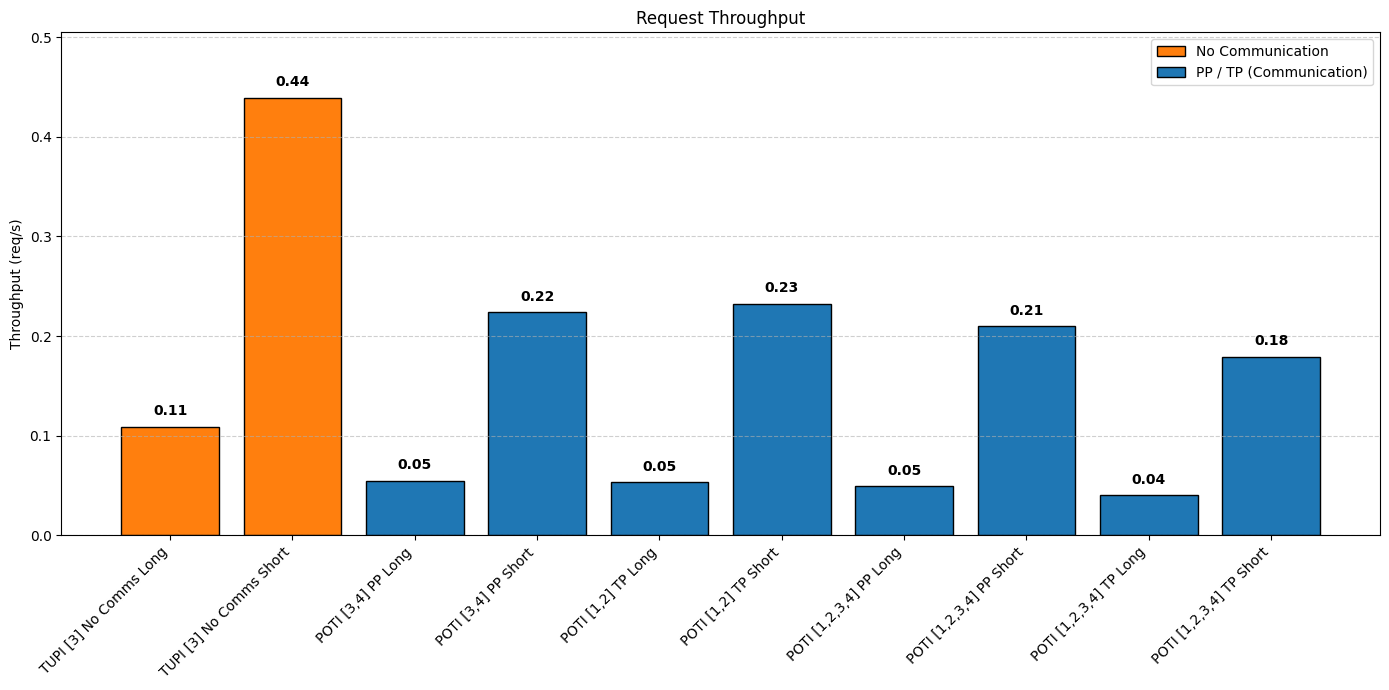

Saved: ../data/figures/02_analysis/request-throughput.png


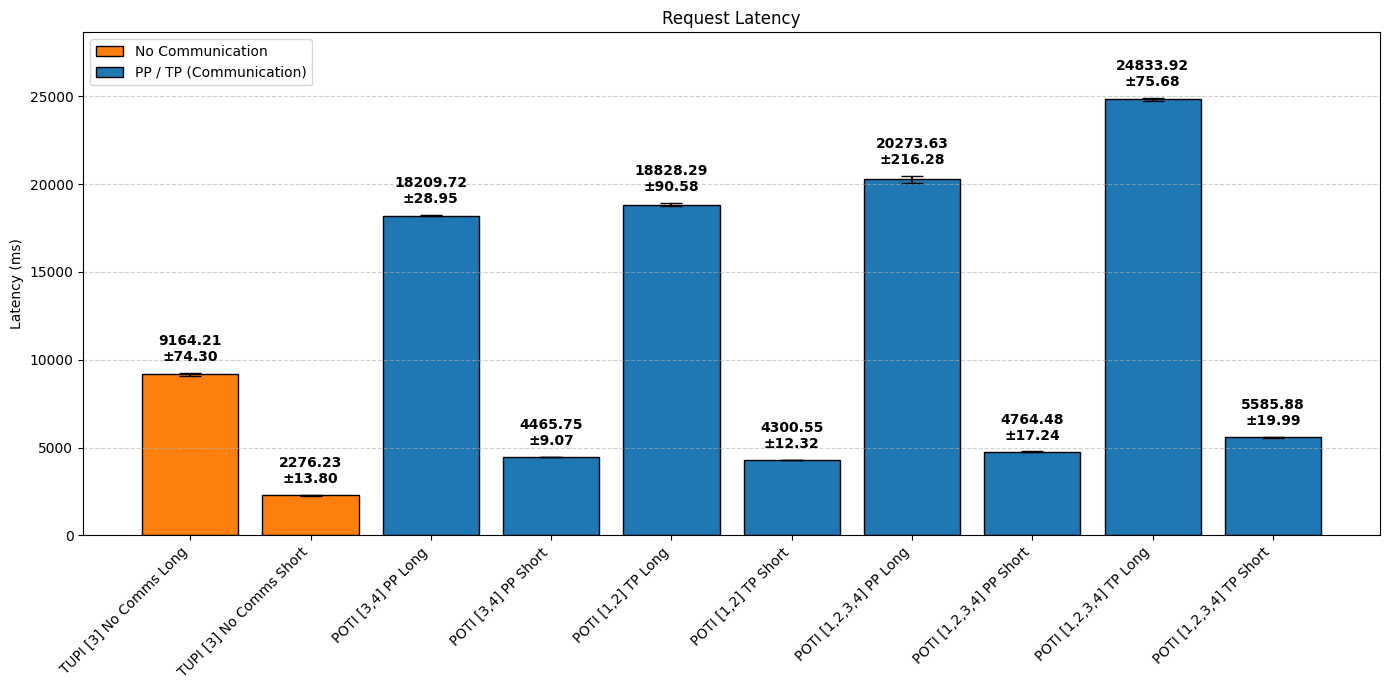

Saved: ../data/figures/02_analysis/request-latency.png


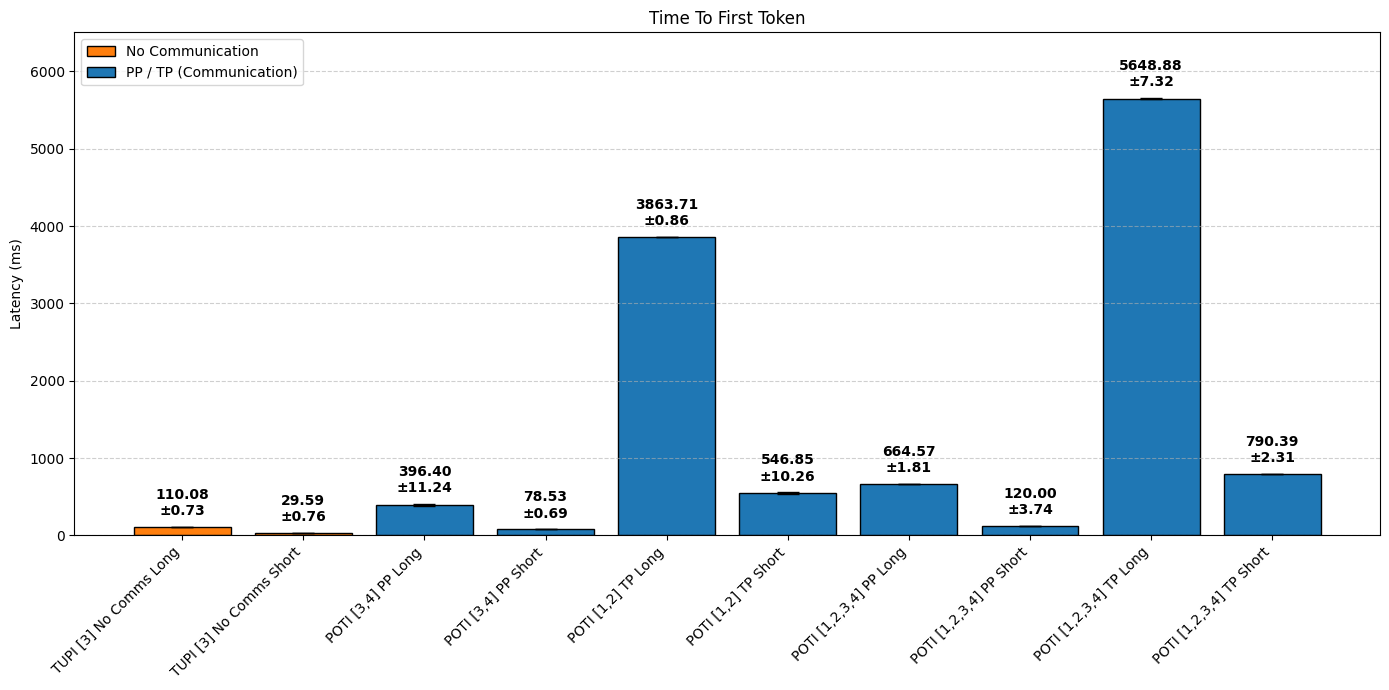

Saved: ../data/figures/02_analysis/time-to-first-token.png


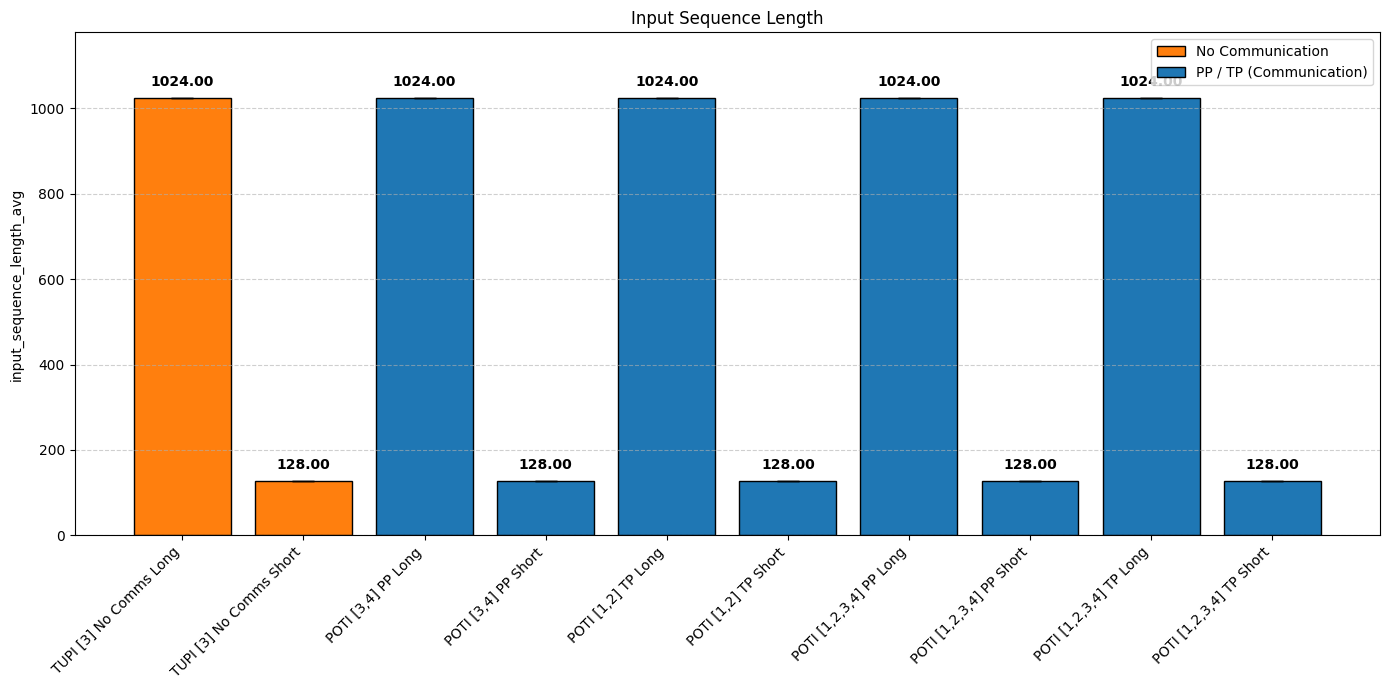

Saved: ../data/figures/02_analysis/input-sequence-length.png


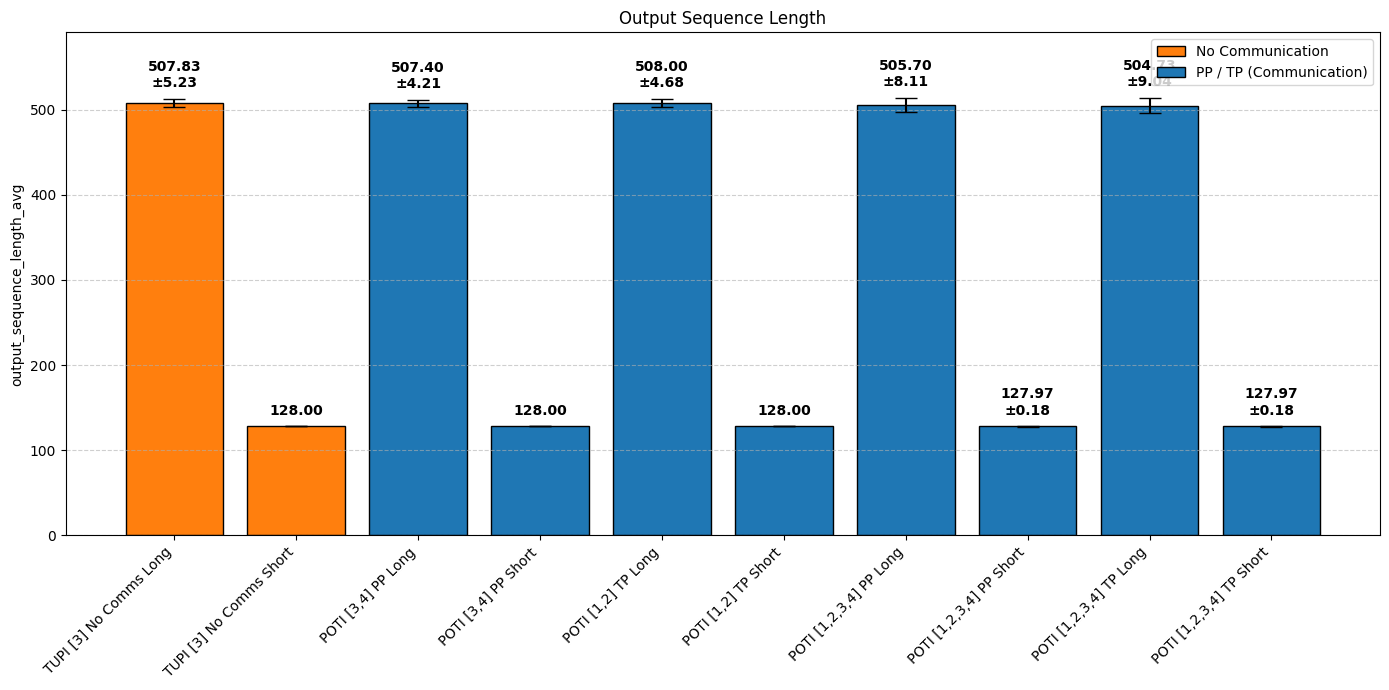

Saved: ../data/figures/02_analysis/output-sequence-length.png


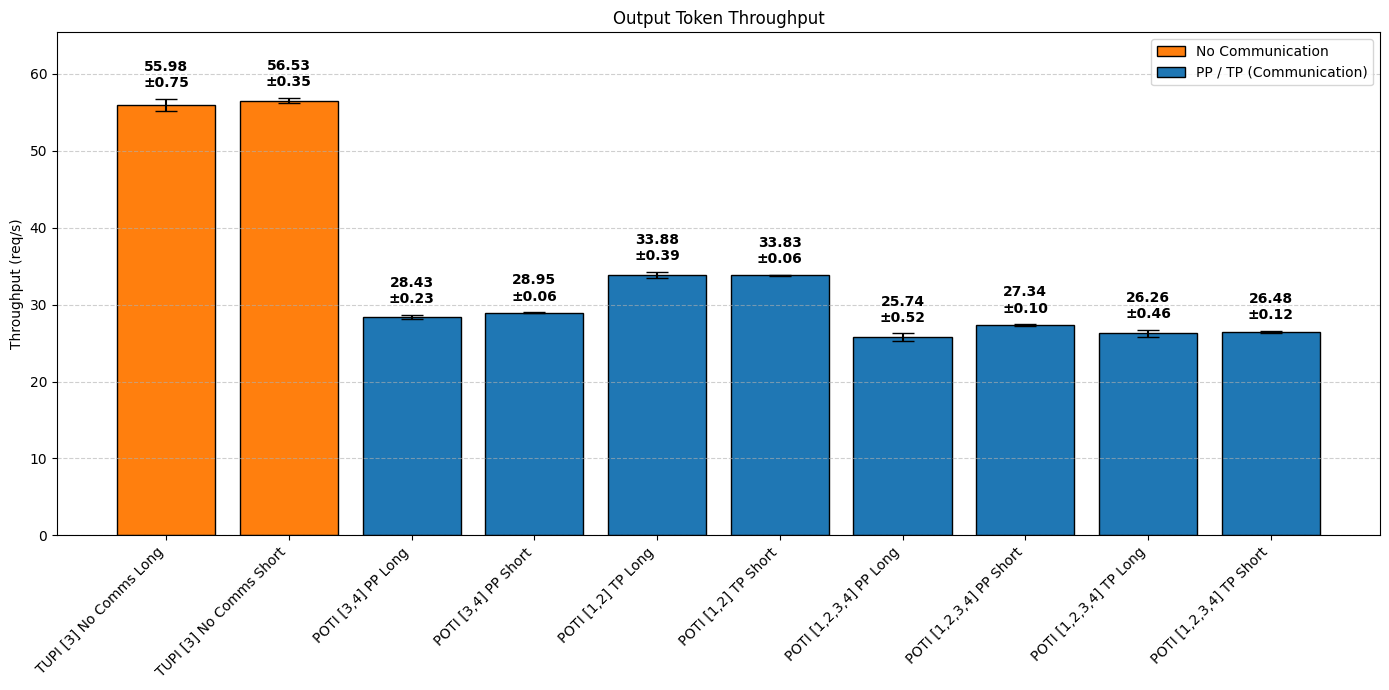

Saved: ../data/figures/02_analysis/output-token-throughput.png


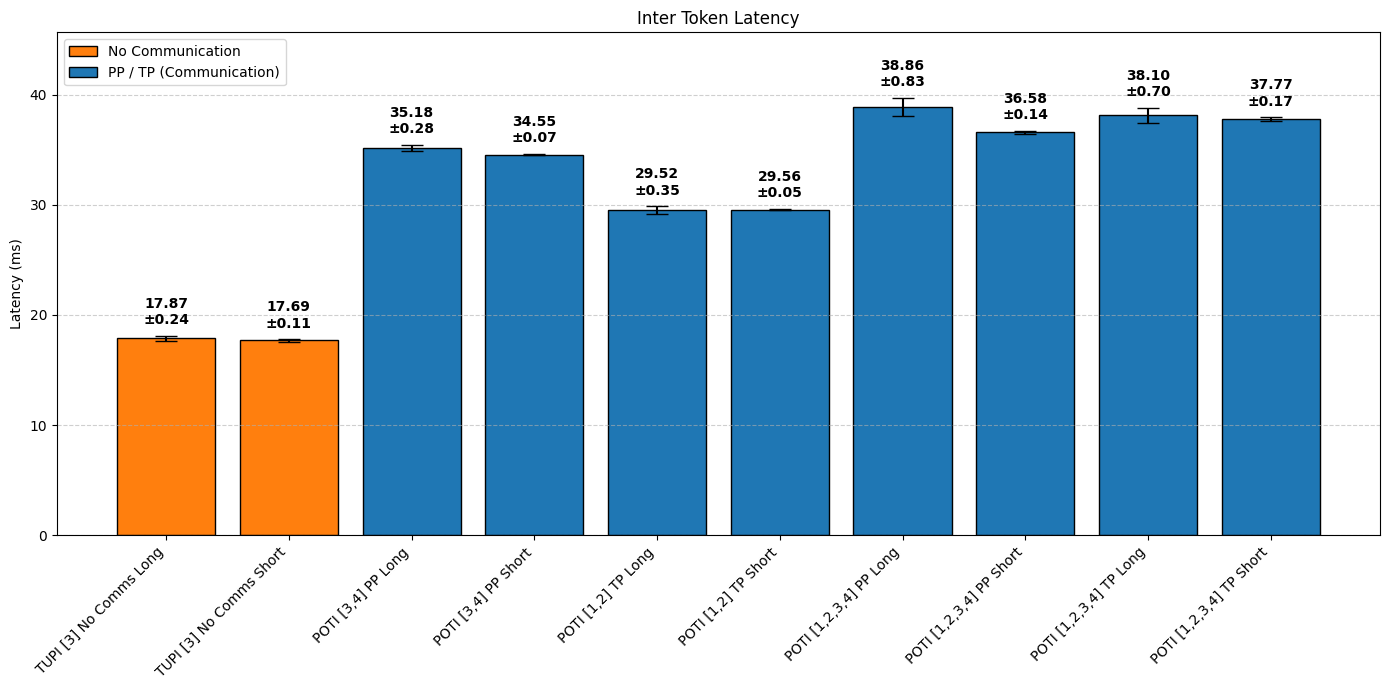

Saved: ../data/figures/02_analysis/inter-token-latency.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import re

output_dir = Path("../data/figures/02_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# FIX is_communication — always derive from parallelism
# =========================================================

df["is_communication"] = df["parallelism"] != "Single GPU"

# =========================================================
# HELPERS
# =========================================================

def pretty_metric_name(metric_name):
    return (
        metric_name
        .replace('_avg_ms', '')
        .replace('_avg', '')
        .replace('_', ' ')
        .title()
    )


def get_ylabel(metric_name):
    if '_ms' in metric_name:
        return 'Latency (ms)'
    if 'throughput' in metric_name:
        return 'Throughput (req/s)'
    return metric_name


def format_machine_nodes(machine_name):
    """
    Convert 'poti[1-4]' → 'POTI [1,2,3,4]'
    Convert 'tupi3'     → 'TUPI [3]'
    """
    machine_name = machine_name.strip()

    # Case: poti[1-4] or poti[1-2]
    match = re.match(r'([a-zA-Z]+)\[(\d+)-(\d+)\]', machine_name)
    if match:
        name  = match.group(1).upper()
        start = int(match.group(2))
        end   = int(match.group(3))
        nodes = ','.join(str(i) for i in range(start, end + 1))
        return f"{name} [{nodes}]"

    # Case: tupi3 (name + single number)
    match = re.match(r'([a-zA-Z]+)(\d+)', machine_name)
    if match:
        name = match.group(1).upper()
        num  = match.group(2)
        return f"{name} [{num}]"

    return machine_name.upper()


def format_experiment_name(row):
    """
    Takes a full dataframe row.
    """
    name         = row['experiment_name']
    machine_name = row['machine_name']
    parallelism  = row['parallelism']

    parts = name.split('_')

    try:
        workload = parts[3].capitalize()
    except Exception:
        workload = ''

    machine_label = format_machine_nodes(machine_name)

    if parallelism == 'Single GPU':
        strategy_label = 'No Comms'
    elif parallelism == 'TP':
        strategy_label = 'TP'
    elif parallelism == 'PP':
        strategy_label = 'PP'
    else:
        strategy_label = parallelism

    return f"{machine_label} {strategy_label} {workload}"


# =========================================================
# MAIN PLOTS
# =========================================================

for avg_col in metrics_to_plot:

    # =====================================================
    # FIND STD COLUMN
    # =====================================================
    if avg_col.endswith('_avg_ms'):
        std_col = avg_col.replace('_avg_ms', '_std_ms')
    else:
        std_col = avg_col.replace('_avg', '_std')

    if avg_col not in df.columns:
        print(f"Skipping {avg_col}: column not found.")
        continue

    # =====================================================
    # BUILD PLOT DATAFRAME
    # =====================================================
    plot_df = df[['experiment_name', 'display_name', 'parallelism', 'machine_name', 'is_communication', avg_col]].copy()

    if std_col in df.columns:
        plot_df[std_col] = df[std_col]

    plot_df = plot_df.dropna(subset=[avg_col])

    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values('experiment_name').reset_index(drop=True)

    plot_df['pretty_name'] = plot_df.apply(format_experiment_name, axis=1)

    # =====================================================
    # X / Y
    # =====================================================
    x = np.arange(len(plot_df))
    y = plot_df[avg_col].values

    has_std = std_col in plot_df.columns and plot_df[std_col].notna().any()
    yerr    = plot_df[std_col].values if has_std else None

    # =====================================================
    # COLORS
    # =====================================================
    colors = [
        'tab:blue' if is_comm else 'tab:orange'
        for is_comm in plot_df['is_communication']
    ]

    # =====================================================
    # FIGURE
    # =====================================================
    plt.figure(figsize=(14, 7))

    plt.bar(
        x,
        y,
        yerr=yerr,
        capsize=8 if has_std else 0,
        color=colors,
        edgecolor='black',
        linewidth=1,
    )

    # =====================================================
    # VALUE LABELS
    # =====================================================
    offset     = 0.02 * np.nanmax(y)
    max_height = 0

    for i, (xi, yi) in enumerate(zip(x, y)):
        label = f"{yi:.2f}"

        if has_std:
            std_val = yerr[i]
            if not np.isnan(std_val) and std_val > 0:
                label     += f"\n±{std_val:.2f}"
                y_pos      = yi + std_val + offset
                max_height = max(max_height, yi + std_val)
            else:
                y_pos      = yi + offset
                max_height = max(max_height, yi)
        else:
            y_pos      = yi + offset
            max_height = max(max_height, yi)

        plt.text(
            xi,
            y_pos,
            label,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
        )

    # =====================================================
    # AXES
    # =====================================================
    plt.ylim(0, max_height * 1.15)
    plt.xticks(x, plot_df['pretty_name'], rotation=45, ha='right')
    plt.ylabel(get_ylabel(avg_col))
    plt.title(pretty_metric_name(avg_col))
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # =====================================================
    # LEGEND
    # =====================================================
    legend_elements = [
        Patch(facecolor='tab:orange',   edgecolor='black', label='No Communication'),
        Patch(facecolor='tab:blue', edgecolor='black', label='PP / TP (Communication)'),
    ]
    plt.legend(handles=legend_elements)

    plt.tight_layout()

    filename = avg_col.replace('_avg_ms', '').replace('_avg', '').replace('_', '-')
    filepath = output_dir / f"{filename}.png"

    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved: {filepath}")

Focusing strictly on the time metrics, the results show a more nuanced trade-off between computation and communication that depends on the inference phase. The single-machine configuration achieves the lowest overall request latency and inter-token latency, as all computation is local and no synchronization or data transfer is required. When tensor parallelism is introduced, latency increases due to frequent inter-GPU communication at every layer, but this overhead remains relatively controlled because computation is still performed concurrently across devices, leading to good inter-token latency during the decode phase.

Pipeline parallelism, however, exhibits contrasting behavior between phases. During prefill, it can achieve significantly lower time to first token (TTFT), especially for long inputs, because different pipeline stages process multiple tokens concurrently once the pipeline is filled. This allows the workload to be effectively distributed across GPUs, reducing the initial response time. In contrast, during the decode phase, where tokens are generated sequentially, pipeline parallelism becomes less efficient. Each token must traverse all stages in order, introducing synchronization delays and idle periods (pipeline bubbles), which increases inter-token latency. As a result, while pipeline parallelism can outperform tensor parallelism in TTFT, it tends to have worse per-token latency and, in many cases, higher overall request latency due to these sequential dependencies.